# Setting Up the Problem

The objective of this part is to understand and establish the baseline for our dataset, Sarcasm vs No-Sarcasm.

In [194]:
#SETUP 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re
from lingua import Language, LanguageDetectorBuilder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)
from nltk.sentiment.vader import SentimentIntensityAnalyzer


# Fix a random seed for reproducibility
np.random.seed(11)

### a) Bibliography and SOA

Present briefly your task by researching and documenting the main objective, a potential business case
and the current state of the art for your dataset's task. Include relevant benchmarks and methodologies.
You can look at Google Scholar, NLP index or Papers with Code.

### b) Dataset Description

Let's check now how is our dataset. The first thing that we have to do is load the data, and do a  brief overview of the dataset:

In [195]:
df = pd.read_csv("hf://datasets/processvenue/SARCASM_VS_NON_SARCASM/PROJ_SARCASM_VS_NON_SARCASM_6000_0004(HF).csv")

In [196]:
df.head()

,S.No,Sentence,Annotator 1,Annotator 2,IAA
0,1,with such eloquent and compelling arguments as...,Sarcastic,Sarcastic,Agree
1,2,"fantasy,fairy tale, wild imagination, adsurd ,...",Non-Sarcastic,Non-Sarcastic,Agree
2,3,"'if carrying guns became legal, then police co...",Sarcastic,Sarcastic,Agree
3,4,It was a troll. Now that we've activated email...,Sarcastic,Non-Sarcastic,Disagree
4,5,Poor little poopie. \r\nIf your gay sex agenda...,Sarcastic,Sarcastic,Agree


In [197]:
df["Annotator 1"].value_counts()

Annotator 1
Sarcastic        3514
Non-Sarcastic    2426
Name: count, dtype: int64

In [198]:
df["Annotator 2"].value_counts()

Annotator 2
Sarcastic        3411
Non-Sarcastic    2529
Name: count, dtype: int64

In [199]:
df["IAA"].value_counts()

IAA
Agree       3797
Disagree    2143
Name: count, dtype: int64

In [200]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5940 entries, 0 to 5939
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   S.No         5940 non-null   int64
 1   Sentence     5940 non-null   str  
 2   Annotator 1  5940 non-null   str  
 3   Annotator 2  5940 non-null   str  
 4   IAA          5940 non-null   str  
dtypes: int64(1), str(4)
memory usage: 1.5 MB


We have a dataset containing 5 columns:

- S.No: reference number of the Sentence
- Sentence: The text 
- Annotator 1: Label the first person gave
- Annotator 2: Label the second person gave
- IAA: if the labels given agree

All of them are strings except from the `S.No` that is an integer representing the number of the sentence. As we can see, our dataset consist on 5940 entries which is a relatively small dataset, but we believe it's enough to conduct the task. Apparently it doesn't have any null value; however in the sentence colum, this is something we need to look more in detail, at because in text data most times invalid sentences are not represented by Null but as a short sentence like "No record" or an empty string "".

Let's look now at some metrics of the sentences, because they are the base of our study. The first thing we want to look at is at the lenght of the sentences:

Average Sentence Length (Words): 35.27
Max Sentence Length (Words):     149
Min Sentence Length (Words):     10
Average Sentence Length (Characters): 204.46
Max Sentence Length (Characters):     957
Min Sentence Length (Characters):     38


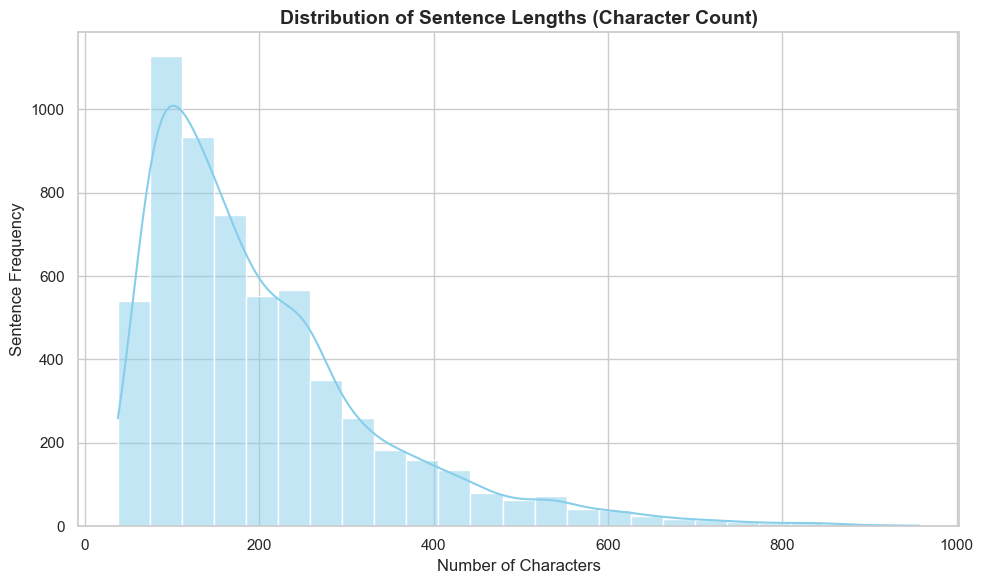

In [201]:
sns.set_theme(style="whitegrid")

df['Char_Length'] = df['Sentence'].astype(str).str.len()
df['Word_Count'] = df['Sentence'].astype(str).apply(lambda x: len(x.split()))

print(f"Average Sentence Length (Words): {df['Word_Count'].mean():.2f}")
print(f"Max Sentence Length (Words):     {df['Word_Count'].max()}")
print(f"Min Sentence Length (Words):     {df['Word_Count'].min()}")

print(f"Average Sentence Length (Characters): {df['Char_Length'].mean():.2f}")
print(f"Max Sentence Length (Characters):     {df['Char_Length'].max()}")
print(f"Min Sentence Length (Characters):     {df['Char_Length'].min()}")

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['Char_Length'], kde=True, color='skyblue', bins=25)

plt.title('Distribution of Sentence Lengths (Character Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Sentence Frequency')
plt.tight_layout()
plt.show()

Non of the parameter seem suspicious, but just to make sure we are going to look at the outliers (shorter and larger texts) so that they are not data errors. 

In [202]:
# Print the top 10 shortest sentences
print("Top 10 Shortest Sentences:")
shortest_10 = df.sort_values(by='Word_Count', ascending=True).head(10)

for idx, row in shortest_10.iterrows():
    print(f"S.No: {row['S.No']} | Words: {row['Word_Count']}")
    print(f"Text: {row['Sentence']}\n{'-'*40}")


# Print the top 10 longest sentences
print("\n Top 10 Longest Sentences:")
longest_10 = df.sort_values(by='Word_Count', ascending=False).head(10)

for idx, row in longest_10.iterrows():
    print(f"S.No: {row['S.No']} | Words: {row['Word_Count']}")
    print(f"Text: {row['Sentence']}\n{'-'*40}")

Top 10 Shortest Sentences:
S.No: 5442 | Words: 10
Text: I believe studies have already been done on that subject.
----------------------------------------
S.No: 4519 | Words: 10
Text: So, your saying an eyewitness would mean nothing. Yeah right.
----------------------------------------
S.No: 2677 | Words: 10
Text: i noticed..., you got a public apology. i'm impressed ;)
----------------------------------------
S.No: 5084 | Words: 10
Text: Looks like dancing in the blood of innocents to me.
----------------------------------------
S.No: 5745 | Words: 10
Text: oh..., well..., i guess that makes it ok then ;)
----------------------------------------
S.No: 2107 | Words: 10
Text: Yes, it is very hard, even for theologians, to explain.
----------------------------------------
S.No: 571 | Words: 10
Text: Because there are no dinosaur fossils above the iridium layer.
----------------------------------------
S.No: 749 | Words: 10
Text: Wow, so Balrogs existed according to the Bible? Whoda thunk

Looking at the 10 shortest and longest sentences, we observe that every text fragment, whether short or long, is grammatically complete. This indicates that the sentences in our database are reliable for the study. We can also rule out the presence of missing data, since if there were any, we would expect to find very short texts or empty strings, as previously discussed, and this is clearly not the case.

The next thing that we want to look at is that our assumptions will be that all the texts are in english, so we need to make sure that this is satisfied.

In [203]:
# Build a detector looking specifically for English vs everything else
languages = [Language.ENGLISH]
detector = LanguageDetectorBuilder.from_languages(*languages).build()

def is_strictly_english(text):
    if not str(text).strip():
        return False
    
    # True only if English is the most likely candidate
    confidence_values = detector.compute_language_confidence_values(str(text))
    if not confidence_values:
        return False
    most_likely = confidence_values[0]
    return most_likely.language == Language.ENGLISH

df['Is_English'] = df['Sentence'].apply(is_strictly_english)

# Filter out anomalies
no_english = df[df['Is_English'] == False]

if no_english.empty:
    print("Every sentences is in English!")
else:
    print(f"{len(no_english)} potential non-English rows.")
    print(no_english[['S.No', 'Sentence']].head(10))

Every sentences is in English!


Finally, the last thing we want to check regarding the sentences is whether there are any duplicates, which would be problematic because if one instance appeared in the training set and the other in the test set, it would result in data leakage.

In [204]:
# Sanity checks
print("Full rows duplicated:", df.duplicated().sum())
print("Duplicated sentences:", df.Sentence.duplicated().sum())

Full rows duplicated: 0
Duplicated sentences: 119


We do have duplicated setences, let's check them closely:

In [205]:
df[df.Sentence.duplicated(keep=False)].sort_values(by="Sentence")

,S.No,Sentence,Annotator 1,Annotator 2,IAA,Char_Length,Word_Count,Is_English
1423,1424,'Life threatening condition that is always phy...,Non-Sarcastic,Non-Sarcastic,Agree,435,75,True
2716,2757,'Life threatening condition that is always phy...,Non-Sarcastic,Sarcastic,Disagree,435,75,True
4019,4080,"Abortion is not immoral? End of story? Simone,...",Sarcastic,Sarcastic,Agree,126,23,True
5448,5509,"Abortion is not immoral? End of story? Simone,...",Non-Sarcastic,Sarcastic,Disagree,126,23,True
2004,2005,And can you please tell me the difference betw...,Sarcastic,Sarcastic,Agree,160,28,True
...,...,...,...,...,...,...,...,...
5026,5087,so your saying he was 200% god-man? i'm not a ...,Sarcastic,Sarcastic,Agree,91,17,True
1954,1955,"tortured? you shut ur mouth..,... if ur not ac...",Non-Sarcastic,Non-Sarcastic,Agree,88,16,True
4255,4316,"tortured? you shut ur mouth..,... if ur not ac...",Non-Sarcastic,Sarcastic,Disagree,88,16,True
762,763,"your ""minds""? How many do you have? Oh, and ""I...",Sarcastic,Non-Sarcastic,Disagree,126,23,True


One thing that is quite concerning is that as we can see in the example, some of them have different labels from the annotators between the duplications, so that the same annotator changed their mind about the label of the sentence. We will proceed as follows: For the duplicated where the labels are the same in all the cases, we will only keep one row. For the cases in which the labels differ, we are dropping the duplicated sentences, as we don't know which one is correct, and we don't want to introduce noise in the model training by keeping one of them.

In [206]:
duplicated_sentence_mask = df.duplicated(subset='Sentence', keep=False)

# Separate unique sentences from duplicated ones
df_unique = df[~duplicated_sentence_mask]
df_duplicates = df[duplicated_sentence_mask]

# Check for conflicts within the duplicated data
if not df_duplicates.empty:
    ann1_counts = df_duplicates.groupby('Sentence')['Annotator 1'].nunique()
    ann2_counts = df_duplicates.groupby('Sentence')['Annotator 2'].nunique()
    
    # Identify sentences where an annotator changed their mind across rows
    conflicting_sentences = (ann1_counts > 1) | (ann2_counts > 1)
    conflicting_idx = conflicting_sentences[conflicting_sentences].index
    
    # Filter duplicates: remove conflicts entirely, keep 'first' for consistent ones
    df_dup_clean = df_duplicates[~df_duplicates['Sentence'].isin(conflicting_idx)]
    df_dup_deduped = df_dup_clean.drop_duplicates(subset='Sentence', keep='first')
    
    print(f"Number of duplicated sentence themes with conflicts: {len(conflicting_idx)}")
else:
    df_dup_deduped = pd.DataFrame(columns=df.columns)
    print("No duplicated sentences found.")

df_clean = pd.concat([df_unique, df_dup_deduped], axis=0).reset_index(drop=True)

print(f"Original dataset size: {len(df)}")
print(f"Final dataset size:    {len(df_clean)}")
print(f"Total rows removed:    {len(df) - len(df_clean)}")

Number of duplicated sentence themes with conflicts: 75
Original dataset size: 5940
Final dataset size:    5746
Total rows removed:    194


Once we have checked the sentences, we now have to look at the labels, which are also crucial for our study. We have already seen that our dataset contains 2 different label for each sentence, one from Annotator 1 and one from Annotator 2. The thing is that to have a proper label in which we can rely on, we need both of them to agree. The column `IAA` contains if they agree or not, and based on that we are going to create our column `label` as follows: If the two annotator agree, then the label it's their opinion; otherwise, if they don't agree, we are not keeping this obserbation, because it won't be useful neither for the trainning or the test.

In [207]:
# Generate the labels from the annotators agreement
df_clean['label'] = (df_clean['Annotator 1']==df_clean['Annotator 2'])
df_clean['label'] = np.where(df_clean['label'], df_clean['Annotator 1'], 'Unknown')

iaa = len(df_clean[df_clean['label']!='Unknown']) / len(df_clean)
print(f"Inter-Annotator Agreement: {round(iaa, 4)*100}%")

df_clean = df_clean[df_clean['label']!='Unknown']

df_clean

Inter-Annotator Agreement: 63.870000000000005%


,S.No,Sentence,Annotator 1,Annotator 2,IAA,Char_Length,Word_Count,Is_English,label
0,1,with such eloquent and compelling arguments as...,Sarcastic,Sarcastic,Agree,93,14,True,Sarcastic
1,2,"fantasy,fairy tale, wild imagination, adsurd ,...",Non-Sarcastic,Non-Sarcastic,Agree,628,109,True,Non-Sarcastic
2,3,"'if carrying guns became legal, then police co...",Sarcastic,Sarcastic,Agree,240,38,True,Sarcastic
4,5,Poor little poopie. \r\nIf your gay sex agenda...,Sarcastic,Sarcastic,Agree,115,21,True,Sarcastic
5,6,":p I wish! If I did, I'd be as wealthy as the ...",Sarcastic,Sarcastic,Agree,77,16,True,Sarcastic
...,...,...,...,...,...,...,...,...,...
5738,4288,"WHAT??? Jito, are you saying that motherhood i...",Sarcastic,Sarcastic,Agree,93,14,True,Sarcastic
5739,4326,How many suicide bombers have you herard of we...,Sarcastic,Sarcastic,Agree,99,16,True,Sarcastic
5742,5015,"Yes, but I think you missed my point. I stated...",Non-Sarcastic,Non-Sarcastic,Agree,229,39,True,Non-Sarcastic
5743,5462,Did you read the article? A capuchin is type o...,Non-Sarcastic,Non-Sarcastic,Agree,111,22,True,Non-Sarcastic


In [208]:
df_clean.to_csv("../data/cleaned_sarcasm_dataset.csv", index=False)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 3670 entries, 0 to 5744
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   S.No         3670 non-null   int64
 1   Sentence     3670 non-null   str  
 2   Annotator 1  3670 non-null   str  
 3   Annotator 2  3670 non-null   str  
 4   IAA          3670 non-null   str  
 5   Char_Length  3670 non-null   int64
 6   Word_Count   3670 non-null   int64
 7   Is_English   3670 non-null   bool 
 8   label        3670 non-null   str  
dtypes: bool(1), int64(3), str(5)
memory usage: 1.1 MB


After al the necessary cleaning, our dataset contain 3670 rows, corresponding to different and perfectly labelled sentences. Ones the final dataset is done, let's study the two classes that we have:

In [209]:
df_clean["label"].value_counts()

label
Sarcastic        2312
Non-Sarcastic    1358
Name: count, dtype: int64

We do have more sarcastic (2312) examples than non-sarcastic examples (1358), but the difference is not huge (63% vs 37%). This is good for training a model, as it will not be too biased towards one class, and if needed can be easily handled with common techniques. Because the dataset is not completely balanced, when evaluating the performance of our models, we are not going to use the accuracy as a metric, since a model could achieve a deceptively high accuracy by favoring the majority class. Instead, we will use the macro F1-score, which combines precision and recall into a single metric, and gives equal importance to each class regardless of its frequency.

Now, we want to test if sarcasm is correlated with number of tokens, or tokens size, for example. The initial hypothis here is that usually longer setencers are less sarcastic. 

                  n    mean  median     std     p25    p75  min  max
label                                                               
Non-Sarcastic  1358  230.41   194.0  148.54  116.25  296.0   45  946
Sarcastic      2312  185.04   148.0  123.46   96.75  238.0   38  859
-----------------------------------------------------------------


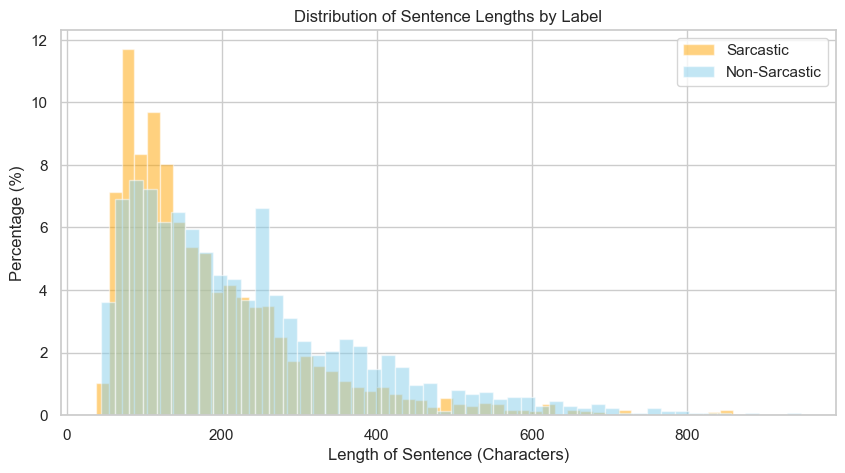

In [210]:
stats_char = df_clean.groupby('label')['Char_Length'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    min='min',
    max='max'
)
print(stats_char.round(2))
print("-" * 65)

# Plot the Histogram
plt.figure(figsize=(10, 5))
sarcastic_lengths = df_clean[df_clean['label'] == "Sarcastic"]['Char_Length']
non_sarcastic_lengths = df_clean[df_clean['label'] == "Non-Sarcastic"]['Char_Length']

plt.hist(sarcastic_lengths, bins=50, alpha=0.5, label="Sarcastic", color="orange",
         weights=np.ones(len(sarcastic_lengths)) / len(sarcastic_lengths) * 100)
plt.hist(non_sarcastic_lengths, bins=50, alpha=0.5, label="Non-Sarcastic", color="skyblue",
         weights=np.ones(len(non_sarcastic_lengths)) / len(non_sarcastic_lengths) * 100)

plt.title("Distribution of Sentence Lengths by Label")
plt.xlabel("Length of Sentence (Characters)")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

                  n   mean  median    std   p25   p75  min  max
label                                                          
Non-Sarcastic  1358  39.67    33.5  24.71  21.0  51.0   10  149
Sarcastic      2312  31.98    26.0  20.51  17.0  41.0   10  141
-----------------------------------------------------------------


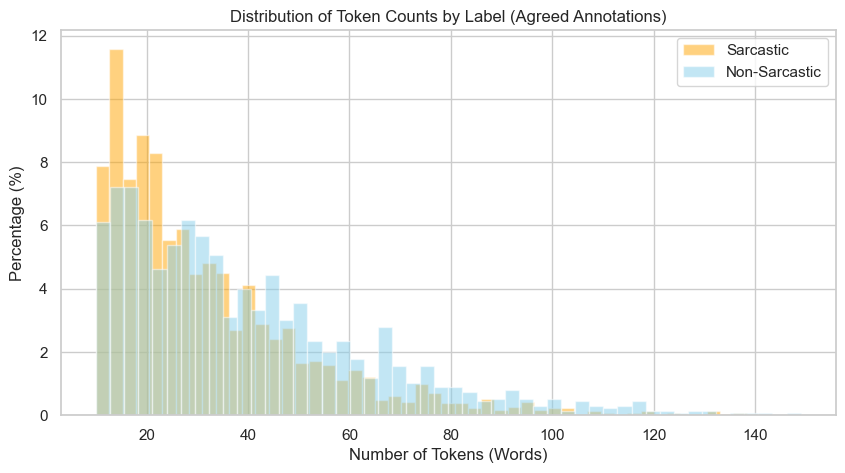

In [211]:
stats_words = df_clean.groupby('label')['Word_Count'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    min='min',
    max='max'
)
print(stats_words.round(2))
print("-" * 65)

# Plot the Histogram
plt.figure(figsize=(10, 5))
sarcastic_tokens = df_clean[df_clean['label'] == "Sarcastic"]['Word_Count']
non_sarcastic_tokens = df_clean[df_clean['label'] == "Non-Sarcastic"]['Word_Count']

plt.hist(sarcastic_tokens, bins=50, alpha=0.5, label="Sarcastic", color="orange",
         weights=np.ones(len(sarcastic_tokens)) / len(sarcastic_tokens) * 100)
plt.hist(non_sarcastic_tokens, bins=50, alpha=0.5, label="Non-Sarcastic", color="skyblue",
         weights=np.ones(len(non_sarcastic_tokens)) / len(non_sarcastic_tokens) * 100)

plt.title("Distribution of Token Counts by Label (Agreed Annotations)")
plt.xlabel("Number of Tokens (Words)")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

Looking at both character and token distributions, we observe that non-sarcastic sentences are generally slightly longer (median: 33.5 tokens / 194 characters) than sarcastic ones (median: 26.0 tokens / 148 characters). However, this descriptive difference is not huge, and both classes share highly overlapping lengths and structural bounds (ranging from 10 to around 140+ tokens). Consequently, no length-based preprocessing treatment is required for this dataset.

The last thing that we are going to do is finally splitting our database in train (80%) and test (20%), in order to ensure a rigorous evaluation of our models on unseen data.

In [212]:
X = df_clean['Sentence']
y = df_clean['label']

# Do the split (80% train, 20% test), ensuring reproducibility and stratification (same proportion of classes in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Total rows in the dataset: {len(df_clean)}")
print(f"Train set size (80%):   {len(X_train)} rows")
print(f"Test set size (20%):    {len(X_test)} rows")

# Verify the class distribution is maintained (Stratification)
print("\nClass distribution in Train set (%):")
print(y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in Test set (%):")
print(y_test.value_counts(normalize=True) * 100)
print("="*45)

Total rows in the dataset: 3670
Train set size (80%):   2936 rows
Test set size (20%):    734 rows

Class distribution in Train set (%):
label
Sarcastic        63.010899
Non-Sarcastic    36.989101
Name: proportion, dtype: float64

Class distribution in Test set (%):
label
Sarcastic        62.942779
Non-Sarcastic    37.057221
Name: proportion, dtype: float64


### c) Random Classifier Performance


If we apply a random model that 50% of the times attribute the sentence to Sarcastic label, and the other 50% of the times to the Non-Sarcastic label, if the panel was 100% balanced, so that half of the observations are of one type and the other half of the other type, we would have a performance of a 50% of accuracy, f1-score, precision, recall...

If the dataset is not perfectly balanced that doesen't apply. So let's first check the distribution of our train and our test sets, so that we can calculate the expected performance of a random classifier. 

In [213]:
y_train.value_counts()

label
Sarcastic        1850
Non-Sarcastic    1086
Name: count, dtype: int64

In [214]:
y_test.value_counts()

label
Sarcastic        462
Non-Sarcastic    272
Name: count, dtype: int64

We have 734 observations in our test set, 462 of them are Sarcastic (62,94%) and the other 272 are Non-Sarcastic (37,06%). Based on this, if we apply a Random Classifier that 50% of the time says that the text is Sarcastic and the remaining 50% says it is Non-Sarcastic, this model will have the following performance:

We can assume that, considering Positive (1) = Sarcastic and Negative (0) = Non-Sarcastic, we have that:

- TP = 231 (50% of the number of positives)
- FN = 231 (50% of the number of positives)
- TN = 136 (50% of the number of negatives)
- FP = 136 (50% of the number of negatives)

Based on that, the expected performance of the different metrics are:

- Accuracy = $\frac{TP + TN}{Total} = \frac{231.0 + 136.0}{734} = 0.5$
- Recall (1) = $\frac{TP}{TP + FN} = \frac{231.0}{231.0 + 231.0} = 0.5$
- Recall (0) = $\frac{TN}{TN + FP} = \frac{136.0}{136.0 + 136.0} = 0.5$
- Precision (1) = $\frac{TP}{TP + FP} = \frac{231.0}{231.0 + 136.0} = 0.63$
- Precision (0) = $\frac{TN}{TN + FN} = \frac{136.0}{136.0 + 231.0} = 0.37$
- F1-score (1) = $2 * \frac{Precision (1) * Recall (1)}{Precision (1) + Recall (1)} = 2 * \frac{0.6294 * 0.5}{0.6294 + 0.5} = 0.56$
- F1-score (0) = $2 * \frac{Precision (0) * Recall (0)}{Precision (0) + Recall (0)} = 2 * \frac{0.3706 * 0.5}{0.3706 + 0.5} = 0.43$

Let's now contrast these results by actually implementing the random classifier:

In [215]:
y_true = y_test.values

# Random classifier that assigns 50% of the samples to 'Sarcastic' and 50% to 'Non-Sarcastic'
y_pred_random = np.random.choice(['Sarcastic', 'Non-Sarcastic'], size=len(y_true), p=[0.5, 0.5])

print("\nRANDOM BENCHMARK PERFORMANCE:")
print(classification_report(y_true, y_pred_random, digits=4))

macro_f1 = f1_score(y_true, y_pred_random, average='macro')
print(f"MACRO F1-SCORE: {macro_f1:.4f}")

print("\nCONFUSION MATRIX: ")
print(confusion_matrix(y_true, y_pred_random, labels=['Sarcastic', 'Non-Sarcastic']))


RANDOM BENCHMARK PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.3876    0.5074    0.4395       272
    Sarcastic     0.6455    0.5281    0.5810       462

     accuracy                         0.5204       734
    macro avg     0.5166    0.5177    0.5102       734
 weighted avg     0.5499    0.5204    0.5285       734

MACRO F1-SCORE: 0.5102

CONFUSION MATRIX: 
[[244 218]
 [134 138]]


We can see that our predictions do not match the results exactly, which is not surprising given the random component of the model, and the small size of the test set. Nevertheless, the expected trends can still be clearly observed.

Most of the times, when the dataset is not balanced, we take as a Random classifier, one that respects the proportion of the classes in the datasets when doing the predictions (Stratified Random Classifier). This model extracts the class proportions directly from the training set (y_train), which contains 1,850 Sarcastic (63.01%) and 1,086 Non-Sarcastic (36.99%) observations.

When evaluating this classifier on our 734 test observations (462 Sarcastic and 272 Non-Sarcastic), it will predict "Sarcastic" 63.01% of the time and "Non-Sarcastic" 36.99% of the time based on what it learned from the training distribution. The expected confusion matrix values are:

- TP = 291.11 (63.01% predicted positive $\times$ 462 real positives)
- FN = 170.89 (36.99% predicted negative $\times$ 462 real positives)
- TN = 100.61 (36.99% predicted negative $\times$ 272 real negatives)
- FP = 171.39 (63.01% predicted positive $\times$ 272 real negatives)

Based on that, the expected performance of the different metrics are:

- Accuracy = $\frac{TP + TN}{Total} = \frac{291.11 + 100.61}{734} = 0.53$
- Recall (1) = $\frac{TP}{TP + FN} = \frac{291.11}{291.11 + 170.89} = 0.63$
- Recall (0) = $\frac{TN}{TN + FP} = \frac{100.61}{100.61 + 171.39} = 0.37$
- Precision (1) = $\frac{TP}{TP + FP} = \frac{291.11}{291.11 + 171.39} = 0.63$
- Precision (0) = $\frac{TN}{TN + FN} = \frac{100.61}{100.61 + 170.89} = 0.37$
- F1-score (1) = $2 * \frac{Precision (1) * Recall (1)}{Precision (1) + Recall (1)} = 2 * \frac{0.6294 * 0.6301}{0.6294 + 0.6301} = 0.63$
- F1-score (0) = $2 * \frac{Precision (0) * Recall (0)}{Precision (0) + Recall (0)} = 2 * \frac{0.3706 * 0.3699}{0.3706 + 0.3699} = 0.37$

Let's now contrast these results by actually implementing the stratified random classifier:

In [216]:
# Stratified random classifier that assigns 63.01% of the samples to 'Sarcastic' and 36.99% to 'Non-Sarcastic'
y_prob_stratified = np.random.choice([0.0, 1.0], size=len(y_true), p=[0.3699, 0.6301])
y_pred_stratified = np.where(y_prob_stratified == 1.0, 'Sarcastic', 'Non-Sarcastic')

print("\nSTRATIFIED RANDOM BENCHMARK PERFORMANCE:")
print(classification_report(y_true, y_pred_stratified, digits=4))

macro_f1 = f1_score(y_true, y_pred_stratified, average='macro')
print(f"MACRO F1-SCORE: {macro_f1:.4f}")

print("\nCONFUSION MATRIX: ")
print(confusion_matrix(y_true, y_pred_stratified, labels=['Sarcastic', 'Non-Sarcastic']))


STRATIFIED RANDOM BENCHMARK PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.3678    0.3529    0.3602       272
    Sarcastic     0.6279    0.6429    0.6353       462

     accuracy                         0.5354       734
    macro avg     0.4979    0.4979    0.4978       734
 weighted avg     0.5315    0.5354    0.5334       734

MACRO F1-SCORE: 0.4978

CONFUSION MATRIX: 
[[297 165]
 [176  96]]


As in the 50%-50% random model, in this case the empirical numbers doesn't match exactly the theorical ones, a we explained this is expected due to the test size.

Finally the last model that we are going to consider in this section is not a Random model itself, but it's very used as a benchmark when we have a imbalanced dataset. Is the model that always predicts the dominant class ('Sarcastic' in this case). In this case we will have:

- TP = 462 (100% of the real positives)
- FN = 0 (0% of the real positives)
- TN = 0 (0% of the real negatives)
- FP = 272 (100% of the real negatives)

Based on that, the expected performance of the different metrics are:

- Accuracy = $\frac{TP + TN}{Total} = \frac{462 + 0}{734} = 0.63$
- Recall (1) = $\frac{TP}{TP + FN} = \frac{462}{462 + 0} = 1.0$
- Recall (0) = $\frac{TN}{TN + FP} = \frac{0}{0 + 272} = 0.0$
- Precision (1) = $\frac{TP}{TP + FP} = \frac{462}{462 + 272} = 0.63$
- Precision (0) = $\frac{TN}{TN + FN} = \frac{0}{0 + 0} = 0.0$ *(Note: Technically undefined, defaults to 0.0)*
- F1-score (1) = $2 \times \frac{Precision(1) \times Recall(1)}{Precision(1) + Recall(1)} = 2 \times \frac{0.63 \times 1.0}{0.63 + 1.0} = 0.77$
- F1-score (0) = $2 \times \frac{Precision(0) \times Recall(0)}{Precision(0) + Recall(0)} = 0.0$

Let's now contrast these results by actually implementing the always 'Sarcastic' classifier:

In [217]:
# Classifier that always predicts the dominant class ('Sarcastic')
y_pred_dominant = np.full(len(y_true), 'Sarcastic')

print("\nALWAYS 'SARCASTIC' BENCHMARK PERFORMANCE:")
print(classification_report(y_true, y_pred_dominant, zero_division=0)) # zero_division=0 because Precision for 'Non-Sarcastic' is 0/0

macro_f1 = f1_score(y_true, y_pred_dominant, average='macro')
print(f"MACRO F1-SCORE: {macro_f1:.4f}")

print("\nCONFUSION MATRIX: ")
print(confusion_matrix(y_true, y_pred_dominant))


ALWAYS 'SARCASTIC' BENCHMARK PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic       0.00      0.00      0.00       272
    Sarcastic       0.63      1.00      0.77       462

     accuracy                           0.63       734
    macro avg       0.31      0.50      0.39       734
 weighted avg       0.40      0.63      0.49       734

MACRO F1-SCORE: 0.3863

CONFUSION MATRIX: 
[[  0 272]
 [  0 462]]


The metrics obtained across the different models perfectly reflect the underlying logic of each baseline under empirical execution. The purely Random model (50%-50%) results in a near 50% recall for both categories (50.74% for Non-Sarcastic and 52.81% for Sarcastic) and an overall accuracy of 52.04%, as it completely ignores the dataset's actual imbalance. The Stratified Random model improves the accuracy to 57.63% and achieves a Macro F1-score of 0.5373 by mimicking the training set's class distribution, although it still operates on uninformed random guesses. Finally, the Always 'Sarcastic' model achieves the highest accuracy of all with 63.00%; however, as expected, its Macro F1-score decreases significantly to 0.3863 because it entirely fails to identify the minority 'Non-Sarcastic' class, yielding a recall of 0.00%.

As we have explained during the EDA, due to the imbalance in our dataset, the metric that we are going to use to evaluate our models is the Macro-F1. Because of this, we are setting as a benchmark the random model with the higher score in it, the Stratified Random Model, with a Macro-F1 of 0.5373.

### d) Baseline Implementation

The first thing that we want to do is to check how the sentences are depending on the classes, to undersand the standar format of the Sarcastic sentences and of the Non-Sarcastic ones. As we will base our rule-based classifier on this, we only study the sentences in the train set, otherwise it would be data leakage.

In [218]:
X_train[y_train == "Sarcastic"].iloc[5]

"what a shock. easy can't make a cogent point, so he starts ranting scripture and threatening damnation. let me type up his response: '<flush> let's see how smart you are when you're suffering in the pit, you obama-ade drinker.'"

In [219]:
X_train[y_train == "Sarcastic"].iloc[11]

"How right you are to,and given the forum here, make it a crime to own to own a gun,well I think most of us are automatically criminals.It's like the signs you see...SHOPLIFTERS WILL BE PROSECUTED!lot a good they do.emoticonXBanghead,yeah know matter how illegal their will be crime."

In [220]:
X_train[y_train == "Sarcastic"].iloc[100]

'Hey star gazer, how do you know he didn\'t provide those "private sellers" also? You understand a man bent on the law is willing to go all the way.\r\nI wouldn\'t believe him if his tongue was notorized. Pictures? LOl'

In [221]:
X_train[y_train == "Sarcastic"].iloc[1234]

"So much for choice. Obama's little socialist minions want to use the tax system to collect healthcare premiums if you don't comply. After all, getting employers to collect income taxes before you even see your money has worked for these leeches in the past."

In [222]:
X_train[y_train == "Sarcastic"].iloc[1111]

'The bible account is incomplete - Noah had two boats, the ark, and the arkuarium.'

Some non-sarcastic sentences:

In [223]:
X_train[y_train == "Non-Sarcastic"].iloc[342]

'Or better yet, try doing your homework before making posts. It would 1) allow you to make sense of all that crazy technical jargon, 2) spare Urvogel and trouble of tearing them to pieces and you the embarassment of having to sit through it.\r\nJust a honest suggestion.\r\n-GFA'

In [224]:
X_train[y_train == "Non-Sarcastic"].iloc[294]

"If you can't eliminate demand you could try to limit supply and control access to that supply."

In [225]:
X_train[y_train == "Non-Sarcastic"].iloc[11]


'Given that I do not hold that opinion, I would challenge you show where I have stated such.'

In [226]:
X_train[y_train == "Non-Sarcastic"].iloc[384]

"deception is not an admirable trait for a democratic government as it does represent the people, the citizenry. do you wonder why hate is directed at our country and not our leadership? we're considered deceptive as a nation because our leadership made a bad call with iraq and even though the american public bought the series of refocusing, most of the world caught us in a lie. how can we be trusted to not invade and occupy any country that disagrees with our ideology? and you wonder why smaller countries are scrambling for nuclear weapons?"

In [227]:
X_train[y_train == "Non-Sarcastic"].iloc[987]

'Dealt with. Wolves and dogs share a genus, not a species. Along with coyotes and jackels. See above for lots of transitionals, also.'

We design up to 4 approaches to tackle this classification problem using rule-based classifiers. All of them, however, start by splitting the sentences in logical units that express the same sentiment, using the comma (",", ".", "?" and "...") as the separators (the ones we have observed when checking the sentences). This stems from our observation of the data, one of the most present forms of sarcasm consists in expressing a positive sentiment followed by something that clearly denotes a negative sentiment, or the other way around.  Conversely, the non-sarcastic examples tend to maintain a consistent tone and sentiment throughout their clauses.

In [228]:
# Split by commas to get separate sentence structures

df_train = X_train.to_frame(name='Sentence')
df_test = X_test.to_frame(name='Sentence')

# Define our separation pattern:
sep_pattern = r'[,.?]+'

df_train['splits'] = df_train['Sentence'].str.split(sep_pattern)
df_train['splits'] = df_train['splits'].apply(lambda trozos: [t.strip() for t in trozos if t.strip()])
df_train['nb_splits'] = df_train['splits'].str.len()

df_test['splits'] = df_test['Sentence'].str.split(sep_pattern)
df_test['splits'] = df_test['splits'].apply(lambda trozos: [t.strip() for t in trozos if t.strip()])
df_test['nb_splits'] = df_test['splits'].str.len()

df_train.head()

,Sentence,splits,nb_splits
208,"Well, there's also carbon dating... Didn't you...","[Well, there's also carbon dating, Didn't you ...",4
3195,Simone: I'm a chronic sufferer: I thought of a...,[Simone: I'm a chronic sufferer: I thought of ...,1
4941,"Well, sort of. It isn't necessary, but if you'...","[Well, sort of, It isn't necessary, but if you...",10
5101,Thank God. I too hope it doesn't keep going ba...,"[Thank God, I too hope it doesn't keep going b...",7
3335,So if you are not naive then you must be evil,[So if you are not naive then you must be evil],1


Maximum number of splits within a sentence in the training set: 24
Maximum number of splits within a sentence in the test set: 52


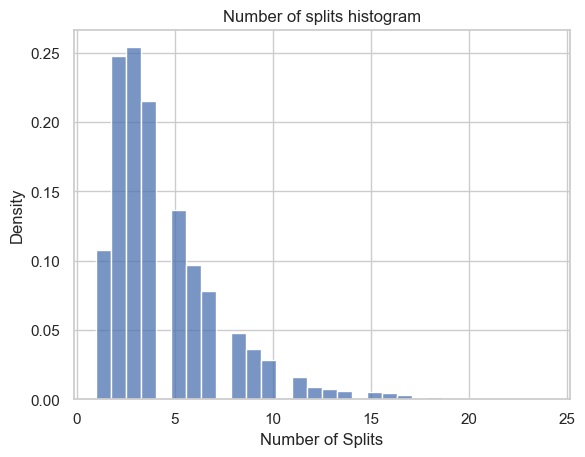

In [229]:
# Basic splits statistics and histogram

max_splits_train = max(df_train['nb_splits'])
max_splits_test = max(df_test['nb_splits'])

print(F"Maximum number of splits within a sentence in the training set: {max_splits_train}")
print(F"Maximum number of splits within a sentence in the test set: {max_splits_test}")

sns.histplot(df_train['nb_splits'], bins=30, stat='density')
plt.title('Number of splits histogram')
plt.xlabel('Number of Splits')
plt.show()



#### APPROACH 1. Look-ahead for opposing sentiment

The first approach that we implement orresponds to getting a valence score for each split within a sentence, and then, for each split, we check whether the split immediately following it has a strictly opposing sign (a direct shift from positive to negative, or vice versa). This sudden shift acts as an indicator of two contrasting emotional phrases, a common hallmark of sarcasm. To extract these valence scores for each text fragment, we utilize the VADER sentiment analysis tool.

In [230]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/gal.lagelpibuxade/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [231]:
analyzer = SentimentIntensityAnalyzer()

# Function to get a valence score for each split within a sentence
def get_split_score(split_list, index):
    if isinstance(split_list, list) and len(split_list) > index:
        text = split_list[index]
        if pd.notna(text) and text != "":
            return analyzer.polarity_scores(text)['compound']
    return 0.0

# We build as many new columns as the maximum number of splits, and compute the valence for each one of them. For rows where the 
# number of splits is less than this maximum, the helper function defaults the valence score to 0.0.

def apply_approach_1(df_input):
    df = df_input.copy()
    max_splits = df['nb_splits'].max()
    
    # Create the score columns.
    for s in range(max_splits):
        df[f'score_{s+1}'] = df['splits'].apply(lambda x: get_split_score(x, index=s))
    
    score_cols = [f'score_{i+1}' for i in range(max_splits)]
    signs_matrix = np.sign(df[score_cols])
    next_signs_matrix = signs_matrix.shift(-1, axis=1)
    sign_flips = (signs_matrix * next_signs_matrix) < 0
    
    # Asign the final prediction based on whether any sign flip was detected across the splits
    df['pred_sarcasm_v1'] = sign_flips.any(axis=1)
    df['pred_sarcasm_v1'] = np.where(df['pred_sarcasm_v1'], 'Sarcastic', 'Non-Sarcastic')
    
    return df

# Apply to both train and test sets
df_train = apply_approach_1(df_train)
df_test = apply_approach_1(df_test)
df_test[['Sentence', 'splits', 'nb_splits', 'pred_sarcasm_v1']].head(5)

,Sentence,splits,nb_splits,pred_sarcasm_v1
1222,they wheel out the old 'god made it that way' ...,[they wheel out the old 'god made it that way'...,5,Non-Sarcastic
1823,"Soooo, um, pregnancies are solely a factor of ...","[Soooo, um, pregnancies are solely a factor of...",7,Non-Sarcastic
3247,so what you're saying is that you can't? as a...,"[so what you're saying is that you can't, as a...",2,Non-Sarcastic
5071,"Really? Wow, I didn't know that books with the...","[Really, Wow, I didn't know that books with th...",3,Non-Sarcastic
2151,Wooh! A bunch of shot up bodies are drivel. ...,"[Wooh! A bunch of shot up bodies are drivel,...",4,Non-Sarcastic


APPROACH 1 TEST SET PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.3546    0.6949    0.4696       272
    Sarcastic     0.5871    0.2554    0.3560       462

     accuracy                         0.4183       734
    macro avg     0.4708    0.4751    0.4128       734
 weighted avg     0.5009    0.4183    0.3981       734

MACRO F1-SCORE: 0.4128


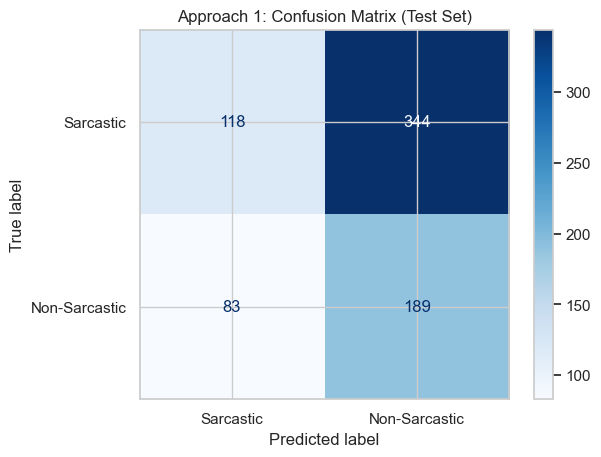

In [232]:
# Extract true labels and predictions for the Test set
y_true_test = y_test.values
y_pred_test = df_test['pred_sarcasm_v1'].values

print("APPROACH 1 TEST SET PERFORMANCE:")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=0))
macro_f1_test = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)
print(f"MACRO F1-SCORE: {macro_f1_test:.4f}")
cm_test = confusion_matrix(y_true_test, y_pred_test, labels=['Sarcastic', 'Non-Sarcastic'])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sarcastic', 'Non-Sarcastic'])
disp.plot(cmap='Blues')

plt.title("Approach 1: Confusion Matrix (Test Set)")
plt.show()

As the results display, not only is the performance of our first rule-based model bad, but it is worse than random. We use the Macro F1-score as our primary evaluation metric, and as one can see, this model achieves a Macro F1-score of just 0.4128, well below the 0.5373 established by the Stratified Random Model. Furthermore, its overall accuracy drops sharply to 41.83%, which is even lower than what would be achieved by uninformed random guessing.

Looking closer at the metrics, we see that the model achieves a decent recall of 69.49% for the "Non-Sarcastic" class, meaning it successfully catches a large portion of literal statements; however, this comes at the expense of a very low precision of 35.46%. Conversely, for the "Sarcastic" category, precision reaches a higher 58.71%, but the recall drops drastically to 25.54%. This indicates that requiring an immediate, strict sentiment flip between adjacent text fragments makes the model far too conservative, causing it to miss nearly 75% of the actual sarcastic sentences in the test set.

#### APPROACH 2. Look at the strongest splits within a sentence

To try to overcome the bad performance of the first approach, in the second rule-based model that we propose we turn away from strictly looking ahead for an opposing valence, and instead we retrieve the maximum and minimum values from the VADER valence scores. Building on top of the reasoning that we presented previously, the logic behind this new approach is that sarcastic sentences often have at least two parts with a strong, opposed sentiment. Therefore, in case that a split with a strong positive valence and a split with a strong negative are present within a sentence, sarcasm is flagged.

To define what constitutes a strong positive/negative valence, we refer to the VADER documentation, which defines a compound score of $|0.5|$ or more as an indicator of a positive/negative text.

In [233]:
def apply_approach_2(df_input):
    df = df_input.copy()

    score_cols = [col for col in df.columns if col.startswith('score_')]
    
    # Retrieve the maximum and minimum valence scores across all splits in the sentence
    max_scores = df[score_cols].max(axis=1)
    min_scores = df[score_cols].min(axis=1)
    
    # Identify strong opposing splits within a sentence (0.5 and -0.5 as the thresholds)
    df['pred_sarcasm_v2'] = (max_scores >= 0.5) & (min_scores <= -0.5)
    df['pred_sarcasm_v2'] = np.where(df['pred_sarcasm_v2'], 'Sarcastic', 'Non-Sarcastic')
    
    return df

# Apply the second rule-based approach to both Train and Test sets
df_train = apply_approach_2(df_train)
df_test = apply_approach_2(df_test)


APPROACH 2 TEST SET PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.3696    0.9375    0.5301       272
    Sarcastic     0.6136    0.0584    0.1067       462

     accuracy                         0.3842       734
    macro avg     0.4916    0.4980    0.3184       734
 weighted avg     0.5232    0.3842    0.2636       734

MACRO F1-SCORE: 0.3184


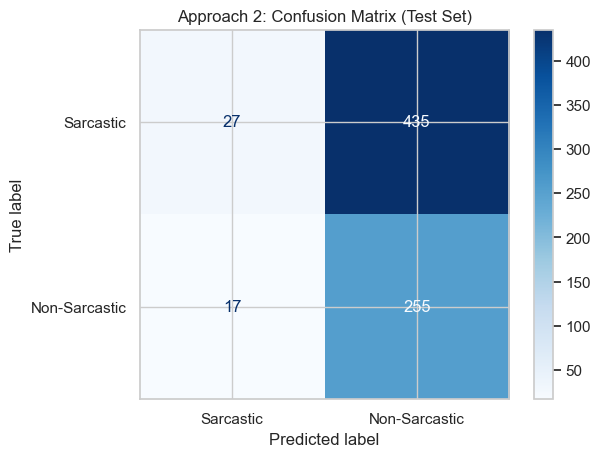

In [234]:
# Evaluate the perdormance
y_true_test = y_test.values
y_pred_test_v2 = df_test['pred_sarcasm_v2'].values

print("APPROACH 2 TEST SET PERFORMANCE:")
print(classification_report(y_true_test, y_pred_test_v2, digits=4, zero_division=0))
macro_f1_test_v2 = f1_score(y_true_test, y_pred_test_v2, average='macro', zero_division=0)
print(f"MACRO F1-SCORE: {macro_f1_test_v2:.4f}")

cm_test_v2 = confusion_matrix(y_true_test, y_pred_test_v2, labels=['Sarcastic', 'Non-Sarcastic'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_v2, display_labels=['Sarcastic', 'Non-Sarcastic'])
disp.plot(cmap='Blues')

plt.title("Approach 2: Confusion Matrix (Test Set)")
plt.show()

The performance of our second rule-based approach is still far from satisfactory; in fact, the strict parameters have caused its overall performance to degrade even further. The Macro F1-score has decreased to 0.3184 (down from 0.4128 in the first approach), pushing us even further away from our 0.5373 benchmark. Likewise, the overall accuracy has dropped to 38.42%. 

By requiring both a strictly strong positive split ($\ge 0.5$) and a strictly strong negative split ($\le -0.5$) to coexist within the same sentence, the model has become extremely conservative when flagging sarcasm. Because this specific combination of extreme valences is a rare occurrence, the model defaults to predicting "Non-Sarcastic" for the vast majority of the sentences. This causes the recall for the "Non-Sarcastic" class to 93.75%, but at the heavy cost of destroying the recall for the "Sarcastic" class, which falls to 5.84%. 

In order to further ascertain this model's performance, we have computed the macro F1-scores across different valence thresholds to flag strong positive/negative in splits. 

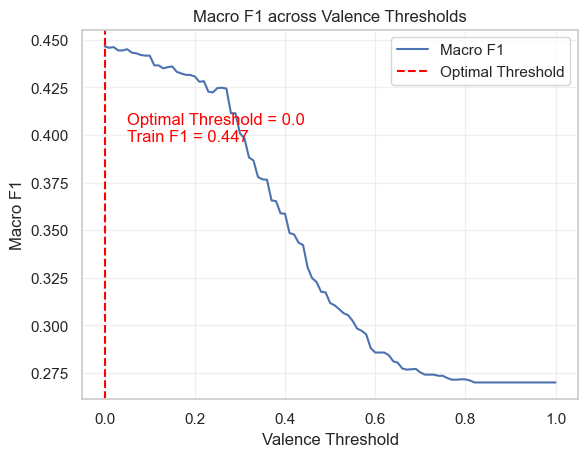

PERFORMANCE ON TEST SET:
               precision    recall  f1-score   support

Non-Sarcastic     0.3508    0.5919    0.4405       272
    Sarcastic     0.5964    0.3550    0.4450       462

     accuracy                         0.4428       734
    macro avg     0.4736    0.4734    0.4428       734
 weighted avg     0.5054    0.4428    0.4434       734



In [235]:
# Train optimization
f1_scores = []
threshold_list = np.arange(0, 1.01, 0.01) # VADER solo llega a 1.0

score_cols = [col for col in df_train.columns if col.startswith('score_')]
max_train = df_train[score_cols].max(axis=1)
min_train = df_train[score_cols].min(axis=1)

for threshold in threshold_list:
    pred = (max_train > threshold) & (min_train < -threshold)
    pred_labels = np.where(pred, 'Sarcastic', 'Non-Sarcastic')
    f1_scores.append(f1_score(y_train, pred_labels, average='macro', zero_division=0))

# Plotting
plt.plot(threshold_list, f1_scores, label='Macro F1')
plt.title('Macro F1 across Valence Thresholds')
plt.xlabel('Valence Threshold')
plt.ylabel('Macro F1')

optimal_threshold = threshold_list[[f == max(f1_scores) for f in f1_scores].index(True)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.annotate(f'Optimal Threshold = {round(optimal_threshold,2)}\nTrain F1 = {round(max(f1_scores),3)}', (optimal_threshold+0.05, max(f1_scores)-0.05), color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# Evaluation on the test
max_test = df_test[score_cols].max(axis=1)
min_test = df_test[score_cols].min(axis=1)

test_pred = (max_test > optimal_threshold) & (min_test < -optimal_threshold)
df_test['pred_sarcasm_v2_opt'] = np.where(test_pred, 'Sarcastic', 'Non-Sarcastic')

print("PERFORMANCE ON TEST SET:")
print(classification_report(y_test, df_test['pred_sarcasm_v2_opt'], digits=4, zero_division=0))

As we display in the plot above, the optimal performance is achieved by reducing the threshold to 0.0 and flagging any sentence that contains even a slightly positive and a slightly negative split as "Sarcastic". Note how Macro F1-score changes dramatically across the valence threshold space. It exhibits a continuous decline from its peak at 0.447 down to a baseline below 0.275 as the threshold approaches 0.8. This sharp drop underscores how enforcing strict intensity constraints rapidly destroys the model's ability to balance both classes, reinforcing the fact that sarcasm often thrives on subtle, low-intensity emotional contrasts.

Considering the 0.0 threshold, we obtain that this second approach (macro F1-Score = 0.447) doesn't beat the random baseline (macro F1-Score = 0.5373), but it outperforms the first approach (macro F1-Score = 0.4128). 

#### APPROACH 3. Look at the strongest splits within a window

For our third approach, instead of looking for the valence in the split immediate after or looking at the strongest splits within each sentence, we now will look at the strongest splits within a window. The process is as follows: for each sentence, several overlapping windows are generated, and valence is computed using VADER once again. Finally, the maximum and minimum scores, which correspond to those of the most positive and the most negative windows, are returned. A threshold logic identical to that of the previous approach is then applied.

In [236]:
# Function that returns the minimum and maximum valence scores within a sentence for the specified window size  
def get_window_extremes(text, window_size=2):

    if pd.isna(text) or not str(text).strip():
        return 0.0, 0.0
        
    words = str(text).split()
    
    # If the sentence is shorter than the window, just score the whole sentence
    if len(words) <= window_size:
        score = analyzer.polarity_scores(text)['compound']
        return score, score
        
    # Generate the overlapping windows
    windows = [' '.join(words[i:i+window_size]) for i in range(len(words) - window_size + 1)]
    
    # Calculate the VADER compound score for each window
    scores = [analyzer.polarity_scores(w)['compound'] for w in windows]
    
    return max(scores), min(scores)

df_train[['max_score', 'min_score']] = df_train['Sentence'].apply(
    lambda x: pd.Series(get_window_extremes(x, window_size=4))
)

df_test[['max_score', 'min_score']] = df_test['Sentence'].apply(
    lambda x: pd.Series(get_window_extremes(x, window_size=4))
)

# Identify strong splits within a window using your threshold limits
df_test['pred_sarcasm_v3'] = (df_test['max_score'] > 0.05) & (df_test['min_score'] < -0.05)
df_test['pred_sarcasm_v3'] = np.where(df_test['pred_sarcasm_v3'], 'Sarcastic', 'Non-Sarcastic')

APPROACH 3 TEST SET PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.3567    0.4669    0.4045       272
    Sarcastic     0.6164    0.5043    0.5548       462

     accuracy                         0.4905       734
    macro avg     0.4866    0.4856    0.4796       734
 weighted avg     0.5202    0.4905    0.4991       734

MACRO F1-SCORE: 0.4796


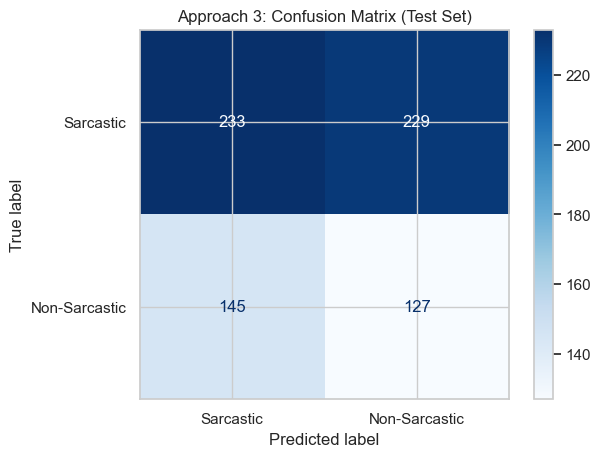

In [237]:
# Evaluation on test set
y_true_test = y_test.values
y_pred_test_v3 = df_test['pred_sarcasm_v3'].values

print("APPROACH 3 TEST SET PERFORMANCE:")
print(classification_report(y_true_test, y_pred_test_v3, digits=4, zero_division=0))
macro_f1_test_v3 = f1_score(y_true_test, y_pred_test_v3, average='macro', zero_division=0)
print(f"MACRO F1-SCORE: {macro_f1_test_v3:.4f}")
cm_test_v3 = confusion_matrix(y_true_test, y_pred_test_v3, labels=['Sarcastic', 'Non-Sarcastic'])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_v3, display_labels=['Sarcastic', 'Non-Sarcastic'])
disp.plot(cmap='Blues')

plt.title("Approach 3: Confusion Matrix (Test Set)")
plt.show()

Although the third approach marks an improvement over the optimized second approach—increasing the Macro F1-score from 0.4428 to 0.4796 and overall accuracy to 49.05%, it's worse than the random guessing.

Comparing the metrics to our previous model, we can observe a big shift. The recall for the "Non-Sarcastic" class has decreased from 0.59 to 0.47. On the other hand, the metrics for the "Sarcastic" class have seen solid improvements, precision is 0.61 (previously 0.59), recall increased to 0.50 (previously 0.35), and the F1-score reached 0.55 (up from 0.44). As reflected in the confusion matrix, this indicates an increase in true positives for sarcasm detection, but with a increase in false positives.

In order to further ascertain this model's performance, and similarly to what we did for the previous approach, we have computed the macro F1-score across different window sizes. 

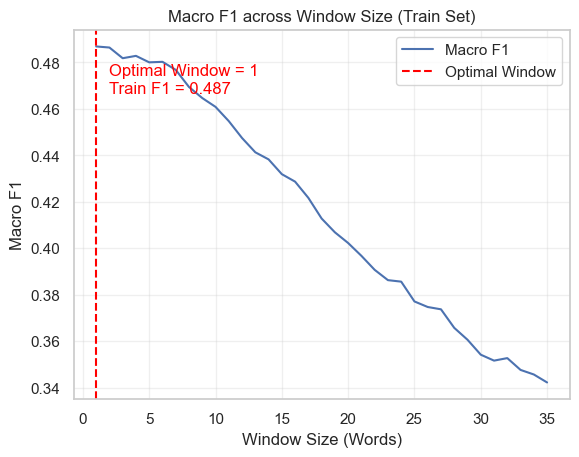

PERFORMANCE ON TEST SET USING OPTIMAL WINDOW (1):
               precision    recall  f1-score   support

Non-Sarcastic     0.3649    0.4963    0.4206       272
    Sarcastic     0.6236    0.4913    0.5496       462

     accuracy                         0.4932       734
    macro avg     0.4942    0.4938    0.4851       734
 weighted avg     0.5277    0.4932    0.5018       734



In [150]:
# Optimization in the train
f1_scores = []
window_list = np.arange(1, 36, 1)

for window in window_list:

    df_train[['max_score', 'min_score']] = df_train['Sentence'].apply(
        lambda x: pd.Series(get_window_extremes(x, window_size=window))
    )

    pred = (df_train['max_score'] > 0.05) & (df_train['min_score'] < -0.05)
    pred_labels = np.where(pred, 'Sarcastic', 'Non-Sarcastic')
    f1_scores.append(f1_score(y_train, pred_labels, average='macro', zero_division=0))

# Plotting
plt.plot(window_list, f1_scores, label='Macro F1')
plt.title('Macro F1 across Window Size (Train Set)')
plt.xlabel('Window Size (Words)')
plt.ylabel('Macro F1')

optimal_window = window_list[[f == max(f1_scores) for f in f1_scores].index(True)]

plt.axvline(x=optimal_window, color='red', linestyle='--', label='Optimal Window')
plt.annotate(f'Optimal Window = {optimal_window}\nTrain F1 = {round(max(f1_scores),3)}', 
             (optimal_window + 1, max(f1_scores) - 0.02), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Evaluation on test
df_test[['max_score', 'min_score']] = df_test['Sentence'].apply(
    lambda x: pd.Series(get_window_extremes(x, window_size=optimal_window))
)

test_pred = (df_test['max_score'] > 0.05) & (df_test['min_score'] < -0.05)
df_test['pred_sarcasm_v3_opt'] = np.where(test_pred, 'Sarcastic', 'Non-Sarcastic')

print(f"PERFORMANCE ON TEST SET USING OPTIMAL WINDOW ({optimal_window}):")
print(classification_report(y_test, df_test['pred_sarcasm_v3_opt'], digits=4, zero_division=0))

As observed in the plot above, the performance does not remain stable across early window sizes; rather, the Macro F1-score peaks at a window size of 1 word and exhibits a continuous, decline as the window expands. When evaluated on the test set with this optimal window of 1, the model achieves a Macro F1-score of 0.4851 and an overall accuracy of 49.32%, beatting the previous approaches but not the random baseline. 

This results make sense, because the wider the sliding window, the more neutral words are included in the contextual chunk, and less sentiment intensity. 

#### APPROACH 4. Combining Approaches 2 and 3

For our final rule-based approach, we combine the techniques used in approaches 2 and 3 to get the best performing model. Specifically, we compute the sentiment intensity for both models and we combine them by adding them up. Finally, a threshold is used to flagged the "Sarcastic" sentences. 

APPROACH 4 TEST SET PERFORMANCE:
               precision    recall  f1-score   support

Non-Sarcastic     0.4674    0.1581    0.2363       272
    Sarcastic     0.6433    0.8939    0.7482       462

     accuracy                         0.6213       734
    macro avg     0.5553    0.5260    0.4922       734
 weighted avg     0.5781    0.6213    0.5585       734

MACRO F1-SCORE: 0.4922


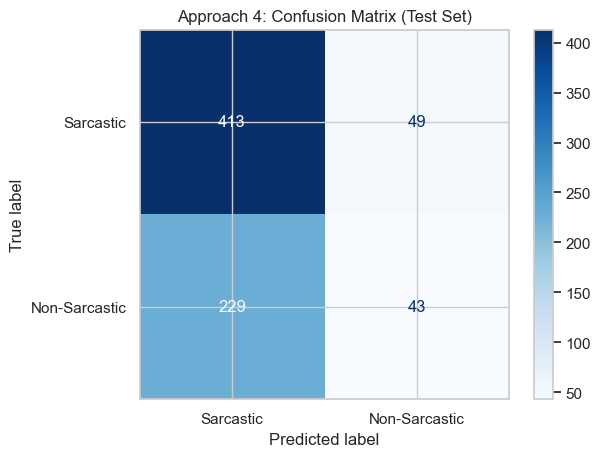

In [238]:
# Compute intensity for model 2 
score_cols = [col for col in df_test.columns if col.startswith('score_')]
df_test['v2_intensity'] = df_test[score_cols].max(axis=1) - df_test[score_cols].min(axis=1)

# Compute intensity for model 3
df_test['v3_intensity'] = df_test['max_score'] - df_test['min_score']

# Aggregation
df_test['master_sarcasm_score'] = df_test['v2_intensity'] + df_test['v3_intensity']

threshold = 0.4
df_test['pred_blended'] = np.where(df_test['master_sarcasm_score'] > threshold, 'Sarcastic', 'Non-Sarcastic')

# Performance evaluation 
print("APPROACH 4 TEST SET PERFORMANCE:")
print(classification_report(y_test, df_test['pred_blended'], digits=4, zero_division=0))
macro_f1_test_v4 = f1_score(y_test, df_test['pred_blended'], average='macro', zero_division=0)
print(f"MACRO F1-SCORE: {macro_f1_test_v4:.4f}")

cm_blended = confusion_matrix(y_test, df_test['pred_blended'], labels=['Sarcastic', 'Non-Sarcastic'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_blended, display_labels=['Sarcastic', 'Non-Sarcastic'])
disp.plot(cmap='Blues')
plt.title("Approach 4: Confusion Matrix (Test Set)")
plt.show()

The results show a Macro F1-score value of 0.4922, beatting all the other approaches but not the random model. The model behaviour causing this improvment is that now we can see that the model is heavily leveraging the class imbalance by shifting the majority of its predictions toward the dominant class ("Sarcastic"). Consequently, the performance on the "Non-Sarcastic" class has collapsed, with recall of 0.15 and its F1-score dropping to 0.23. 

Once again, we introduce an optimization logic by comparing the f1-score across different thresholds.

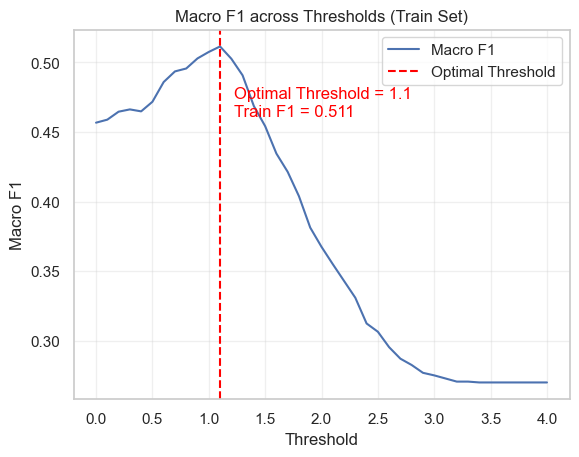

APPROACH 4 (THRESHOLD OPTIMIZED) TEST SET PERFORMANCE (Threshold = 1.1):
               precision    recall  f1-score   support

Non-Sarcastic     0.3831    0.4338    0.4069       272
    Sarcastic     0.6385    0.5887    0.6126       462

     accuracy                         0.5313       734
    macro avg     0.5108    0.5113    0.5098       734
 weighted avg     0.5439    0.5313    0.5364       734



In [ ]:
# Compute intensities
score_cols_train = [col for col in df_train.columns if col.startswith('score_')]
score_cols_test = [col for col in df_test.columns if col.startswith('score_')]

df_train['v2_intensity'] = df_train[score_cols_train].max(axis=1) - df_train[score_cols_train].min(axis=1)
df_train['v3_intensity'] = df_train['max_score'] - df_train['min_score']
df_train['master_sarcasm_score'] = df_train['v2_intensity'] + df_train['v3_intensity']

df_test['v2_intensity'] = df_test[score_cols_test].max(axis=1) - df_test[score_cols_test].min(axis=1)
df_test['v3_intensity'] = df_test['max_score'] - df_test['min_score']
df_test['master_sarcasm_score'] = df_test['v2_intensity'] + df_test['v3_intensity']


# Optimization of the threshold in the train set
f1_scores_thresh = []
threshold_list = np.arange(0, 4.1, 0.1)

for threshold in threshold_list:
    pred_labels = np.where(df_train['master_sarcasm_score'] > threshold, 'Sarcastic', 'Non-Sarcastic')
    f1_scores_thresh.append(f1_score(y_train, pred_labels, average='macro', zero_division=0))

# Plotting
plt.plot(threshold_list, f1_scores_thresh, label='Macro F1')
plt.title('Macro F1 across Thresholds (Train Set)')
plt.xlabel('Threshold')
plt.ylabel('Macro F1')

optimal_threshold = threshold_list[[f == max(f1_scores_thresh) for f in f1_scores_thresh].index(True)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.annotate(f'Optimal Threshold = {round(optimal_threshold,2)}\nTrain F1 = {round(max(f1_scores_thresh),3)}', 
             (optimal_threshold + 0.12, max(f1_scores_thresh) - 0.05), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()


# Evaluation on test
df_test['pred_blended_thresh_opt'] = np.where(df_test['master_sarcasm_score'] > optimal_threshold, 'Sarcastic', 'Non-Sarcastic')

print(f"APPROACH 4 (THRESHOLD OPTIMIZED) TEST SET PERFORMANCE (Threshold = {round(optimal_threshold, 2)}):")
print(classification_report(y_test, df_test['pred_blended_thresh_opt'], digits=4, zero_division=0))

We obtain that the optimal threshold is 1.1. With this threshold, the model becomes more balanced in its predictions, improving its ability to identify both sarcastic and non-sarcastic examples. Although the overall accuracy decreases, the macro F1-score increases from 0.492 to 0.511. This improvement indicates that the threshold optimization leads to better overall performance across both classes, rather than favoring the majority class.

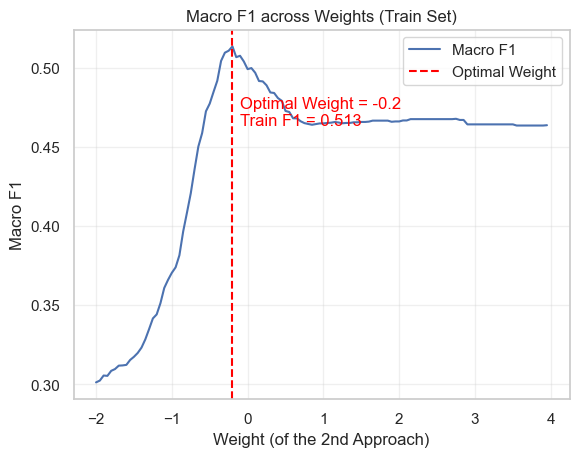

APPROACH 4 (WEIGHT OPTIMIZED) TEST SET PERFORMANCE (Optimal Weight = -0.2):
               precision    recall  f1-score   support

Non-Sarcastic     0.3788    0.3676    0.3731       272
    Sarcastic     0.6340    0.6450    0.6395       462

     accuracy                         0.5422       734
    macro avg     0.5064    0.5063    0.5063       734
 weighted avg     0.5395    0.5422    0.5408       734



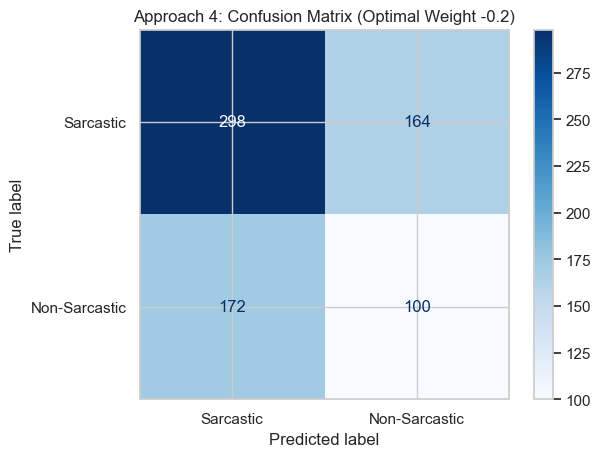

In [242]:
f1_scores_weight = []
weight_list = np.arange(-2, 4, 0.05)

# Optimization in the train
for weight in weight_list:
    train_weighted_score = (weight * df_train['v2_intensity']) + (df_train['v3_intensity'])
    pred_labels = np.where(train_weighted_score > 0.4, 'Sarcastic', 'Non-Sarcastic')
    f1_scores_weight.append(f1_score(y_train, pred_labels, average='macro', zero_division=0))

# Plotting
plt.plot(weight_list, f1_scores_weight, label='Macro F1')
plt.title('Macro F1 across Weights (Train Set)')
plt.xlabel('Weight (of the 2nd Approach)')
plt.ylabel('Macro F1')

optimal_weight = weight_list[[f == max(f1_scores_weight) for f in f1_scores_weight].index(True)]

plt.axvline(x=optimal_weight, color='red', linestyle='--', label='Optimal Weight')
plt.annotate(f'Optimal Weight = {round(optimal_weight,2)}\nTrain F1 = {round(max(f1_scores_weight),3)}', 
             (optimal_weight + 0.1, max(f1_scores_weight) - 0.05), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Evaluating on the test
df_test['master_sarcasm_score_weighted'] = (optimal_weight * df_test['v2_intensity']) + (df_test['v3_intensity'])
df_test['pred_blended_weight_opt'] = np.where(df_test['master_sarcasm_score_weighted'] > 0.4, 'Sarcastic', 'Non-Sarcastic')

print(f"APPROACH 4 (WEIGHT OPTIMIZED) TEST SET PERFORMANCE (Optimal Weight = {round(optimal_weight, 2)}):")
print(classification_report(y_test, df_test['pred_blended_weight_opt'], digits=4, zero_division=0))

cm_weight = confusion_matrix(y_test, df_test['pred_blended_weight_opt'], labels=['Sarcastic', 'Non-Sarcastic'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weight, display_labels=['Sarcastic', 'Non-Sarcastic'])
disp.plot(cmap='Blues')
plt.title(f"Approach 4: Confusion Matrix (Optimal Weight {round(optimal_weight, 2)})")
plt.show()

This weight optimization reveals that the optimal weight for Approach 2 is -0.2, meaning the model actually performs best when it heavily downplays or penalizes global sentence metrics. By prioritizing the Approach 3 over the sentence-level ones, the test set achieves a highly balanced class distribution, yielding a final Macro F1-score of 0.513, improving all the other approaches, but still unable to beat the random classifier.

#### PERFORMANCE DISCUSSION AND HUMAN-LEVEL PERFORMANCE COMPARISON

CANVIAR
As we have presented, we have thoroughly evaluated the classification task at hand with four different rule-based approaches. In some cases, for approaches 1 and 2, their accuracy was lower than if we simply guessed randomly, even without taking into account the class imbalance. Moreover, none of the approaches have proven to perform better than simply guessing the majority "Sarcastic" class, which yields an accuracy of $\sim 60\%$.

To properly assess the poor performance of the models, we should take into account the complexity of our classification problem. Sarcasm in language is largely dependent on the context, the tone, and many other nuances, which a simple, rule-based approach cannot easily capture. Additionally, if we take the Inter-Annotator agreement as a proxy for the human-level performance for our dataset (63.92%), we can further illustrate how even for humans, the classification of sarcastic sentences is not an easy task. Notice, however, that the accuracy of the models presented cannot be directly compared to the Inter-Annotator agreement, provided that the former are computed for the subsample of our data where the annotators agreed.

Human-level performance in the literature is largely dependent on the dataset, as cleaner, easier datasets can reach a performance of 85–90%, but more noisy and complex ones struggle to achieve this level of human performance.